# Complete PPG Time Series EDA Notebook

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.signal import find_peaks
from scipy.fft import fft, fftfreq

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

import warnings
warnings.filterwarnings('ignore')


In [4]:
FILE_PATH = 'sakshi_ppg_20260611T074737_len148s.csv'
df = pd.read_csv(FILE_PATH)

print(df.shape)
display(df.head())


(7423, 6)


,seq,timestamp_ms,red,ir,red_corrected,ir_corrected
0,1,135093,40603,100950,-10.788063,-4.396235
1,2,135113,40616,100938,2.142789,-15.105669
2,3,135133,40603,100945,-12.051503,-7.542110
3,4,135153,40612,100939,-0.769166,-14.245303
4,5,135173,40621,100933,8.087457,-20.552190


In [5]:
print(df.info())
print(df.describe())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7423 entries, 0 to 7422
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   seq            7423 non-null   int64  
 1   timestamp_ms   7423 non-null   int64  
 2   red            7423 non-null   int64  
 3   ir             7423 non-null   int64  
 4   red_corrected  7423 non-null   float64
 5   ir_corrected   7423 non-null   float64
dtypes: float64(2), int64(4)
memory usage: 348.1 KB
None
               seq   timestamp_ms           red             ir  red_corrected  \
count  7423.000000    7423.000000   7423.000000    7423.000000    7423.000000   
mean   3694.687727  209046.679644  40766.814226  100317.870538       7.390210   
std    2126.863458   42580.840520    253.111665     535.399046      88.544662   
min       1.000000  135093.000000  40080.000000   98942.000000    -232.529984   
25%    1856.500000  172245.500000  40649.500000  100198.000000     -54.934158   

In [6]:
missing_df = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_%': round(df.isnull().mean()*100,2)
})
display(missing_df)


,Missing_Count,Missing_%
seq,0,0.0
timestamp_ms,0,0.0
red,0,0.0
ir,0,0.0
red_corrected,0,0.0
ir_corrected,0,0.0


In [7]:
df['time_sec'] = (df['timestamp_ms'] - df['timestamp_ms'].min())/1000

df['red_roll_mean'] = df['red_corrected'].rolling(50).mean()
df['red_roll_std'] = df['red_corrected'].rolling(50).std()

df['ir_roll_mean'] = df['ir_corrected'].rolling(50).mean()
df['ir_roll_std'] = df['ir_corrected'].rolling(50).std()

df['red_diff'] = df['red_corrected'].diff()
df['ir_diff'] = df['ir_corrected'].diff()

df['red_diff2'] = df['red_diff'].diff()
df['ir_diff2'] = df['ir_diff'].diff()

df['signal_energy'] = df['red_corrected']**2 + df['ir_corrected']**2


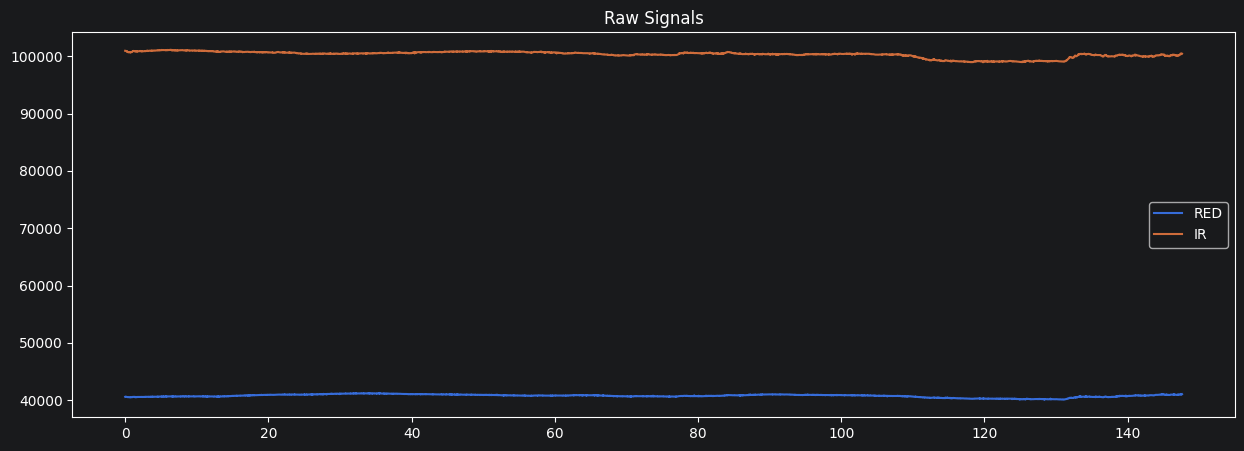

In [9]:
plt.figure(figsize=(15,5))
plt.plot(df['time_sec'], df['red'], label='RED')
plt.plot(df['time_sec'], df['ir'], label='IR')
plt.legend()
plt.title('Raw Signals')
plt.show()


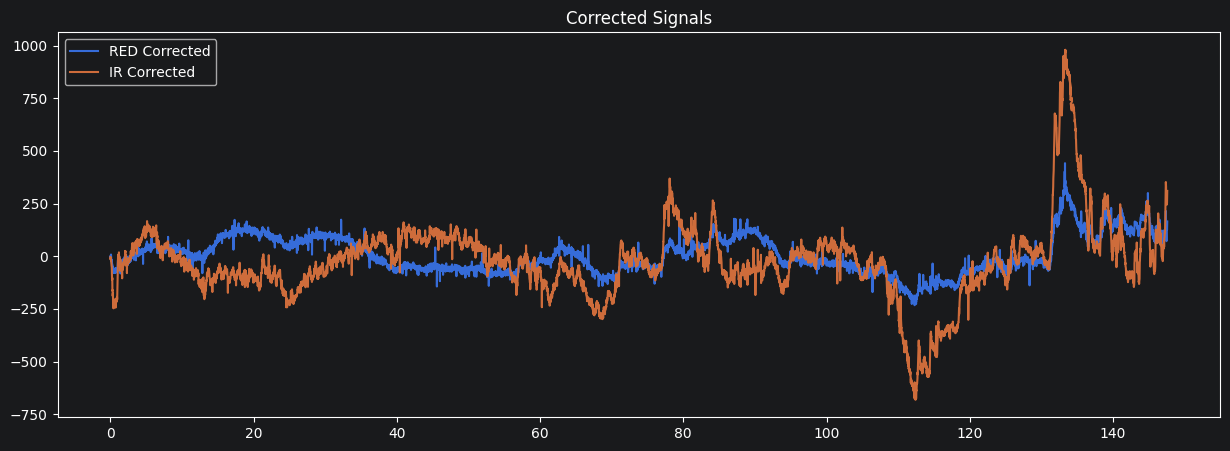

In [10]:
plt.figure(figsize=(15,5))
plt.plot(df['time_sec'], df['red_corrected'], label='RED Corrected')
plt.plot(df['time_sec'], df['ir_corrected'], label='IR Corrected')
plt.legend()
plt.title('Corrected Signals')
plt.show()


In [11]:
time_diff = df['timestamp_ms'].diff().dropna().mean()
sampling_rate = 1000/time_diff
print('Sampling Rate:', sampling_rate)


Sampling Rate: 50.289322835499306


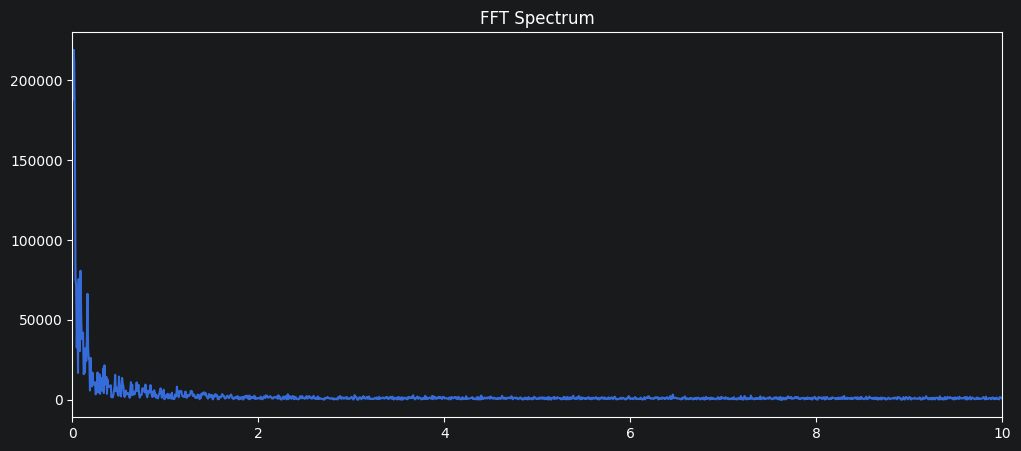

Dominant Frequency: 0.013549595267546625
Estimated BPM: 0.8129757160527975


In [12]:
signal = df['red_corrected'].values
N = len(signal)

yf = fft(signal)
xf = fftfreq(N, d=1/sampling_rate)

mask = xf > 0
xf = xf[mask]
yf = np.abs(yf[mask])

plt.figure(figsize=(12,5))
plt.plot(xf,yf)
plt.xlim(0,10)
plt.title('FFT Spectrum')
plt.show()

dominant_frequency = xf[np.argmax(yf)]
print('Dominant Frequency:', dominant_frequency)
print('Estimated BPM:', dominant_frequency*60)


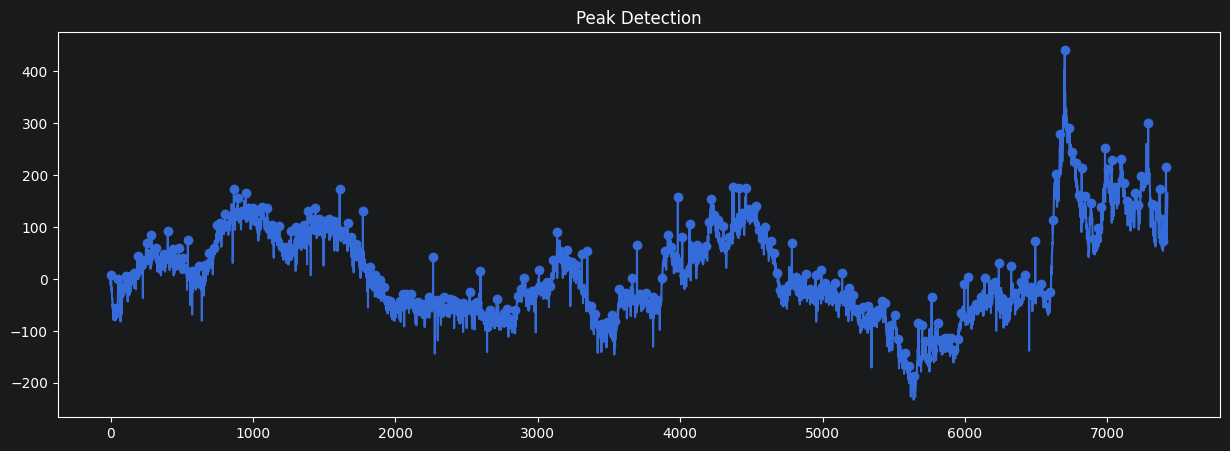

Heart Rate: 113.23213946289407


In [13]:
peaks,_ = find_peaks(df['red_corrected'], distance=int(sampling_rate*0.4))

plt.figure(figsize=(15,5))
plt.plot(df['red_corrected'])
plt.scatter(peaks, df['red_corrected'].iloc[peaks])
plt.title('Peak Detection')
plt.show()

peak_times = df.iloc[peaks]['time_sec'].values
rr = np.diff(peak_times)
print('Heart Rate:', 60/np.mean(rr))


In [14]:
result = adfuller(df['red_corrected'].dropna())

print('ADF Statistic:', result[0])
print('P-value:', result[1])

if result[1] < 0.05:
    print('Stationary')
else:
    print('Not Stationary')


ADF Statistic: -2.536448944342657
P-value: 0.10685585151495264
Not Stationary


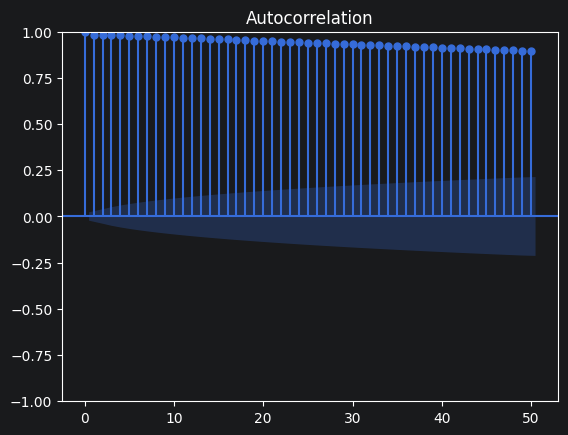

In [15]:
plot_acf(df['red_corrected'].dropna(), lags=50)
plt.show()


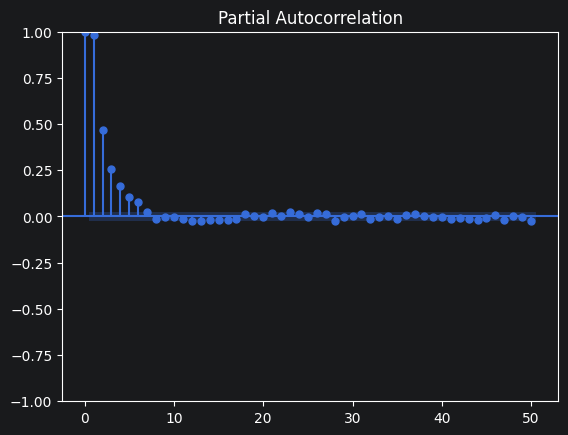

In [16]:
plot_pacf(df['red_corrected'].dropna(), lags=50)
plt.show()


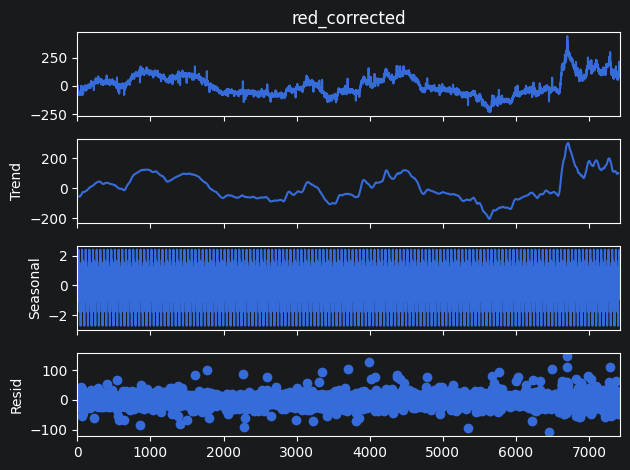

In [17]:
period = int(sampling_rate)

decomp = seasonal_decompose(
    df['red_corrected'],
    model='additive',
    period=period
)

decomp.plot()
plt.show()


In [18]:
signal_power = np.mean(df['red_corrected']**2)

noise = df['red_corrected'] - df['red_roll_mean']
noise_power = np.mean(noise.dropna()**2)

snr = 10*np.log10(signal_power/noise_power)

print('SNR (dB):', snr)


SNR (dB): 11.703926477786684


Outliers: 49


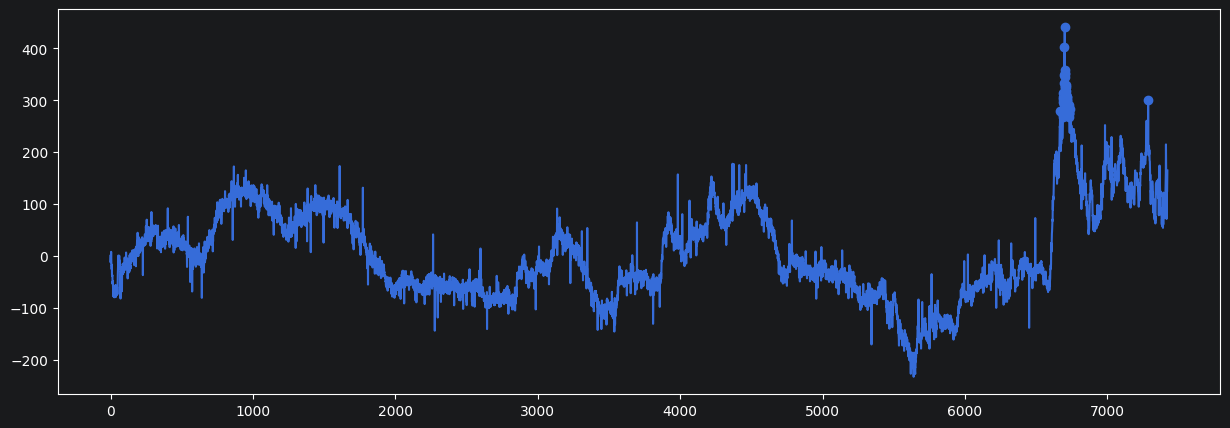

In [19]:
Q1 = df['red_corrected'].quantile(0.25)
Q3 = df['red_corrected'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

outliers = df[(df['red_corrected'] < lower) | (df['red_corrected'] > upper)]

print('Outliers:', len(outliers))

plt.figure(figsize=(15,5))
plt.plot(df['red_corrected'])
plt.scatter(outliers.index, outliers['red_corrected'])
plt.show()


In [20]:
df.to_csv('ppg_feature_engineered.csv', index=False)
print('Feature engineered dataset saved.')


Feature engineered dataset saved.
